In [1]:
from pathlib import Path

import cobra
from cobra.io import load_model
from cobra.flux_analysis import find_blocked_reactions

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
output_dir = Path("outputs")
tables_dir = output_dir / "tables"
figures_dir = output_dir / "figures"

for folder in [output_dir, tables_dir, figures_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Output folders are ready.")

Output folders are ready.


In [3]:
models = {
    "iML1515": load_model("iML1515"),
    "iJO1366": load_model("iJO1366")
}

for model_name, model_obj in models.items():
    print("=" * 60)
    print("Model:", model_name)
    print("Model ID:", model_obj.id)
    print("Number of reactions:", len(model_obj.reactions))
    print("Number of metabolites:", len(model_obj.metabolites))
    print("Number of genes:", len(model_obj.genes))
    print("Objective:", model_obj.objective.expression)

Output()

Model: iML1515
Model ID: iML1515
Number of reactions: 2712
Number of metabolites: 1877
Number of genes: 1516
Objective: 1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Model: iJO1366
Model ID: iJO1366
Number of reactions: 2583
Number of metabolites: 1805
Number of genes: 1367
Objective: 1.0*BIOMASS_Ec_iJO1366_core_53p95M - 1.0*BIOMASS_Ec_iJO1366_core_53p95M_reverse_5c8b1


In [4]:
conditions = {
    "glucose_aerobic": {
        "carbon_source": "EX_glc__D_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "fructose_aerobic": {
        "carbon_source": "EX_fru_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "galactose_aerobic": {
        "carbon_source": "EX_gal_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "glycerol_aerobic": {
        "carbon_source": "EX_glyc_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "succinate_aerobic": {
        "carbon_source": "EX_succ_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "acetate_aerobic": {
        "carbon_source": "EX_ac_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "glucose_anaerobic": {
        "carbon_source": "EX_glc__D_e",
        "oxygen": False,
        "carbon_uptake": 10
    }
}

In [5]:
required_reactions = sorted({
    params["carbon_source"] for params in conditions.values()
} | {"EX_o2_e"})

for model_name, model_obj in models.items():
    print("=" * 60)
    print("Checking model:", model_name)

    for reaction_id in required_reactions:
        if reaction_id in model_obj.reactions:
            print(reaction_id, "FOUND")
        else:
            print(reaction_id, "NOT FOUND")

Checking model: iML1515
EX_ac_e FOUND
EX_fru_e FOUND
EX_gal_e FOUND
EX_glc__D_e FOUND
EX_glyc_e FOUND
EX_o2_e FOUND
EX_succ_e FOUND
Checking model: iJO1366
EX_ac_e FOUND
EX_fru_e FOUND
EX_gal_e FOUND
EX_glc__D_e FOUND
EX_glyc_e FOUND
EX_o2_e FOUND
EX_succ_e FOUND


In [6]:
def set_medium_from_default(base_model, carbon_source, oxygen=True, carbon_uptake=10):
    """
    Set medium condition using the model's default medium as a base.
    This keeps the essential nutrients already defined in the model
    and changes only the carbon source and oxygen availability.
    """

    model_condition = base_model.copy()
    medium = model_condition.medium.copy()

    carbon_sources_to_remove = [
        "EX_glc__D_e",
        "EX_fru_e",
        "EX_gal_e",
        "EX_glyc_e",
        "EX_succ_e",
        "EX_ac_e",
        "EX_lac__D_e",
        "EX_lac__L_e",
        "EX_pyr_e",
        "EX_man_e"
    ]

    for source in carbon_sources_to_remove:
        if source in medium:
            medium[source] = 0

    medium[carbon_source] = carbon_uptake

    if "EX_o2_e" in model_condition.reactions:
        if oxygen:
            medium["EX_o2_e"] = 1000
        else:
            medium["EX_o2_e"] = 0

    model_condition.medium = medium

    return model_condition

In [7]:
def analyze_model_condition(base_model, model_name, condition_name, carbon_source, oxygen, carbon_uptake=10):
    """
    Apply one medium condition to one model, run FBA,
    and extract comparable summary metrics.
    """

    model_condition = set_medium_from_default(
        base_model=base_model,
        carbon_source=carbon_source,
        oxygen=oxygen,
        carbon_uptake=carbon_uptake
    )

    solution = model_condition.optimize()

    nonzero_fluxes = int((solution.fluxes.abs() > 1e-9).sum())
    zero_fluxes = int((solution.fluxes.abs() <= 1e-9).sum())

    blocked_reactions = find_blocked_reactions(model_condition)
    num_blocked = len(blocked_reactions)
    blocked_fraction = num_blocked / len(model_condition.reactions)

    summary = {
        "model_name": model_name,
        "model_id": model_condition.id,
        "condition": condition_name,
        "carbon_source": carbon_source,
        "oxygen_available": oxygen,
        "carbon_uptake": carbon_uptake,
        "solution_status": solution.status,
        "objective_value": solution.objective_value,
        "num_reactions": len(model_condition.reactions),
        "num_metabolites": len(model_condition.metabolites),
        "num_genes": len(model_condition.genes),
        "num_nonzero_fluxes": nonzero_fluxes,
        "num_zero_fluxes": zero_fluxes,
        "num_blocked_reactions": num_blocked,
        "blocked_reaction_fraction": blocked_fraction
    }

    flux_df = solution.fluxes.reset_index()
    flux_df.columns = ["reaction_id", "flux"]
    flux_df["absolute_flux"] = flux_df["flux"].abs()
    flux_df["model_name"] = model_name
    flux_df["condition"] = condition_name
    flux_df = flux_df.sort_values("absolute_flux", ascending=False)

    safe_name = f"{model_name}_{condition_name}"

    flux_df.to_csv(tables_dir / f"{safe_name}_fluxes.csv", index=False)

    blocked_df = pd.DataFrame({
        "model_name": model_name,
        "condition": condition_name,
        "blocked_reaction_id": blocked_reactions
    })

    blocked_df.to_csv(tables_dir / f"{safe_name}_blocked_reactions.csv", index=False)

    return summary, flux_df

In [8]:
all_model_summaries = []
all_model_flux_tables = {}

for model_name, model_obj in models.items():
    for condition_name, params in conditions.items():
        print("=" * 80)
        print("Running model:", model_name)
        print("Running condition:", condition_name)

        summary, flux_df = analyze_model_condition(
            base_model=model_obj,
            model_name=model_name,
            condition_name=condition_name,
            carbon_source=params["carbon_source"],
            oxygen=params["oxygen"],
            carbon_uptake=params["carbon_uptake"]
        )

        all_model_summaries.append(summary)
        all_model_flux_tables[(model_name, condition_name)] = flux_df

model_comparison_df = pd.DataFrame(all_model_summaries)

model_comparison_df

Running model: iML1515
Running condition: glucose_aerobic
Running model: iML1515
Running condition: fructose_aerobic
Running model: iML1515
Running condition: galactose_aerobic
Running model: iML1515
Running condition: glycerol_aerobic
Running model: iML1515
Running condition: succinate_aerobic
Running model: iML1515
Running condition: acetate_aerobic
Running model: iML1515
Running condition: glucose_anaerobic
Running model: iJO1366
Running condition: glucose_aerobic
Running model: iJO1366
Running condition: fructose_aerobic
Running model: iJO1366
Running condition: galactose_aerobic
Running model: iJO1366
Running condition: glycerol_aerobic
Running model: iJO1366
Running condition: succinate_aerobic
Running model: iJO1366
Running condition: acetate_aerobic
Running model: iJO1366
Running condition: glucose_anaerobic


,model_name,model_id,condition,carbon_source,oxygen_available,carbon_uptake,solution_status,objective_value,num_reactions,num_metabolites,num_genes,num_nonzero_fluxes,num_zero_fluxes,num_blocked_reactions,blocked_reaction_fraction
0,iML1515,iML1515,glucose_aerobic,EX_glc__D_e,True,10,optimal,0.876997,2712,1877,1516,431,2281,968,0.356932
1,iML1515,iML1515,fructose_aerobic,EX_fru_e,True,10,optimal,0.876997,2712,1877,1516,432,2280,967,0.356563
2,iML1515,iML1515,galactose_aerobic,EX_gal_e,True,10,optimal,0.867593,2712,1877,1516,436,2276,966,0.356195
3,iML1515,iML1515,glycerol_aerobic,EX_glyc_e,True,10,optimal,0.494713,2712,1877,1516,433,2279,973,0.358776
4,iML1515,iML1515,succinate_aerobic,EX_succ_e,True,10,optimal,0.450086,2712,1877,1516,430,2282,973,0.358776
5,iML1515,iML1515,acetate_aerobic,EX_ac_e,True,10,optimal,0.210099,2712,1877,1516,433,2279,973,0.358776
6,iML1515,iML1515,glucose_anaerobic,EX_glc__D_e,False,10,optimal,0.157540,2712,1877,1516,435,2277,1043,0.384587
7,iJO1366,iJO1366,glucose_aerobic,EX_glc__D_e,True,10,optimal,0.982372,2583,1805,1367,438,2145,878,0.339915
8,iJO1366,iJO1366,fructose_aerobic,EX_fru_e,True,10,optimal,0.982372,2583,1805,1367,440,2143,889,0.344173
9,iJO1366,iJO1366,galactose_aerobic,EX_gal_e,True,10,optimal,0.972003,2583,1805,1367,445,2138,887,0.343399


In [9]:
model_comparison_path = tables_dir / "ecoli_model_comparison_iML1515_iJO1366_summary.csv"

model_comparison_df.to_csv(model_comparison_path, index=False)

print("Saved:", model_comparison_path)

Saved: outputs\tables\ecoli_model_comparison_iML1515_iJO1366_summary.csv


In [10]:
model_report_table = model_comparison_df[
    [
        "model_name",
        "condition",
        "carbon_source",
        "oxygen_available",
        "objective_value",
        "num_nonzero_fluxes",
        "num_blocked_reactions",
        "blocked_reaction_fraction"
    ]
].copy()

model_report_table["objective_value"] = model_report_table["objective_value"].round(4)
model_report_table["blocked_reaction_fraction"] = model_report_table["blocked_reaction_fraction"].round(4)

model_report_table

,model_name,condition,carbon_source,oxygen_available,objective_value,num_nonzero_fluxes,num_blocked_reactions,blocked_reaction_fraction
0,iML1515,glucose_aerobic,EX_glc__D_e,True,0.8770,431,968,0.3569
1,iML1515,fructose_aerobic,EX_fru_e,True,0.8770,432,967,0.3566
2,iML1515,galactose_aerobic,EX_gal_e,True,0.8676,436,966,0.3562
3,iML1515,glycerol_aerobic,EX_glyc_e,True,0.4947,433,973,0.3588
4,iML1515,succinate_aerobic,EX_succ_e,True,0.4501,430,973,0.3588
5,iML1515,acetate_aerobic,EX_ac_e,True,0.2101,433,973,0.3588
6,iML1515,glucose_anaerobic,EX_glc__D_e,False,0.1575,435,1043,0.3846
7,iJO1366,glucose_aerobic,EX_glc__D_e,True,0.9824,438,878,0.3399
8,iJO1366,fructose_aerobic,EX_fru_e,True,0.9824,440,889,0.3442
9,iJO1366,galactose_aerobic,EX_gal_e,True,0.9720,445,887,0.3434


In [11]:
model_report_path = tables_dir / "ecoli_model_comparison_iML1515_iJO1366_report_table.csv"

model_report_table.to_csv(model_report_path, index=False)

print("Saved:", model_report_path)

Saved: outputs\tables\ecoli_model_comparison_iML1515_iJO1366_report_table.csv


In [12]:
pivot_objective = model_comparison_df.pivot(
    index="condition",
    columns="model_name",
    values="objective_value"
)

pivot_objective

model_name,iJO1366,iML1515
condition,,
acetate_aerobic,0.247199,0.210099
fructose_aerobic,0.982372,0.876997
galactose_aerobic,0.972003,0.867593
glucose_aerobic,0.982372,0.876997
glucose_anaerobic,0.241502,0.157540
glycerol_aerobic,0.562790,0.494713
succinate_aerobic,0.492484,0.450086


Saved: outputs\figures\ecoli_model_comparison_objective_value.png


<Figure size 1000x500 with 0 Axes>

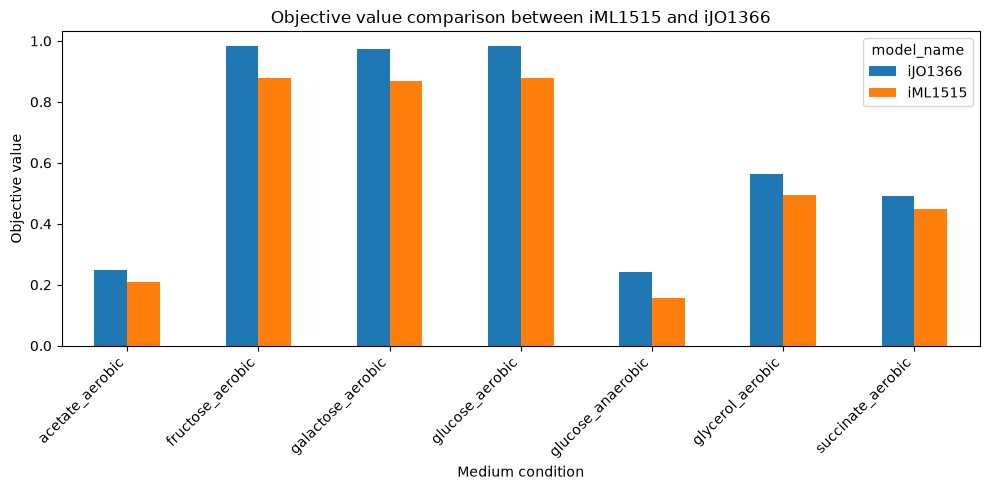

Saved: outputs\figures\ecoli_model_comparison_blocked_reactions.png


<Figure size 1000x500 with 0 Axes>

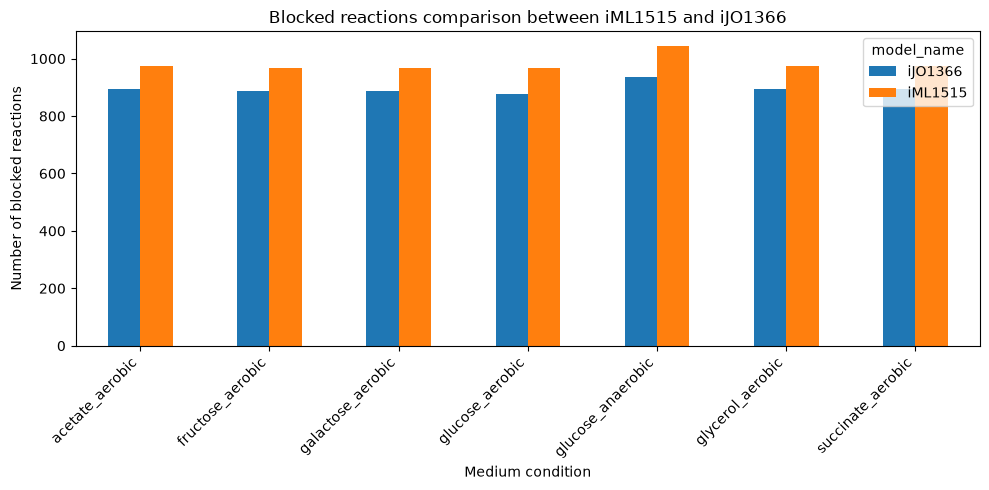

Saved: outputs\figures\ecoli_model_comparison_active_fluxes.png


<Figure size 1000x500 with 0 Axes>

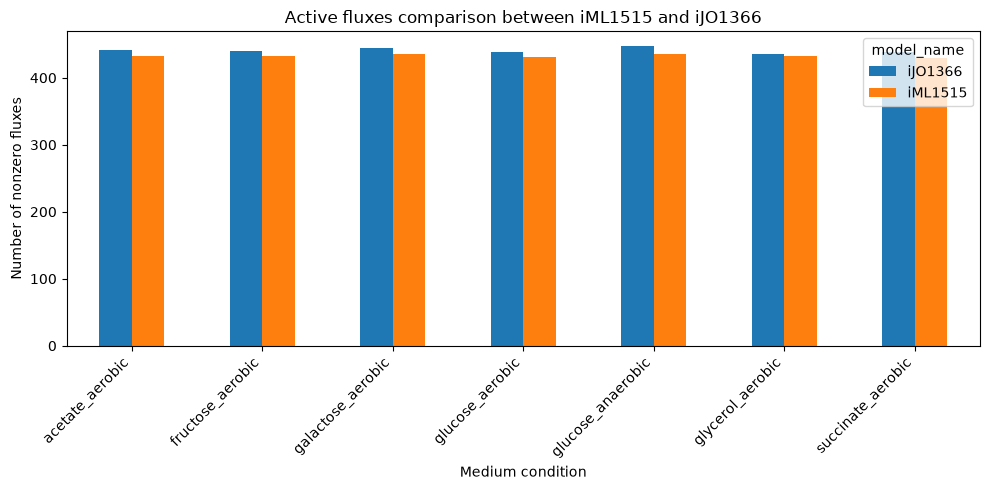

In [13]:
plt.figure(figsize=(10, 5))

ax = pivot_objective.plot(kind="bar", figsize=(10, 5))

plt.title("Objective value comparison between iML1515 and iJO1366")
plt.xlabel("Medium condition")
plt.ylabel("Objective value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

figure_path = figures_dir / "ecoli_model_comparison_objective_value.png"
plt.savefig(figure_path, dpi=300)

print("Saved:", figure_path)
plt.show()

pivot_blocked = model_comparison_df.pivot(
    index="condition",
    columns="model_name",
    values="num_blocked_reactions"
)

pivot_blocked

plt.figure(figsize=(10, 5))

ax = pivot_blocked.plot(kind="bar", figsize=(10, 5))

plt.title("Blocked reactions comparison between iML1515 and iJO1366")
plt.xlabel("Medium condition")
plt.ylabel("Number of blocked reactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

figure_path = figures_dir / "ecoli_model_comparison_blocked_reactions.png"
plt.savefig(figure_path, dpi=300)

print("Saved:", figure_path)
plt.show()

pivot_active = model_comparison_df.pivot(
    index="condition",
    columns="model_name",
    values="num_nonzero_fluxes"
)

pivot_active

plt.figure(figsize=(10, 5))

ax = pivot_active.plot(kind="bar", figsize=(10, 5))

plt.title("Active fluxes comparison between iML1515 and iJO1366")
plt.xlabel("Medium condition")
plt.ylabel("Number of nonzero fluxes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

figure_path = figures_dir / "ecoli_model_comparison_active_fluxes.png"
plt.savefig(figure_path, dpi=300)

print("Saved:", figure_path)
plt.show()



In [14]:
condition_order = [
    "glucose_aerobic",
    "fructose_aerobic",
    "galactose_aerobic",
    "glycerol_aerobic",
    "succinate_aerobic",
    "acetate_aerobic",
    "glucose_anaerobic"
]

Saved: outputs\figures\ecoli_model_comparison_objective_value.png


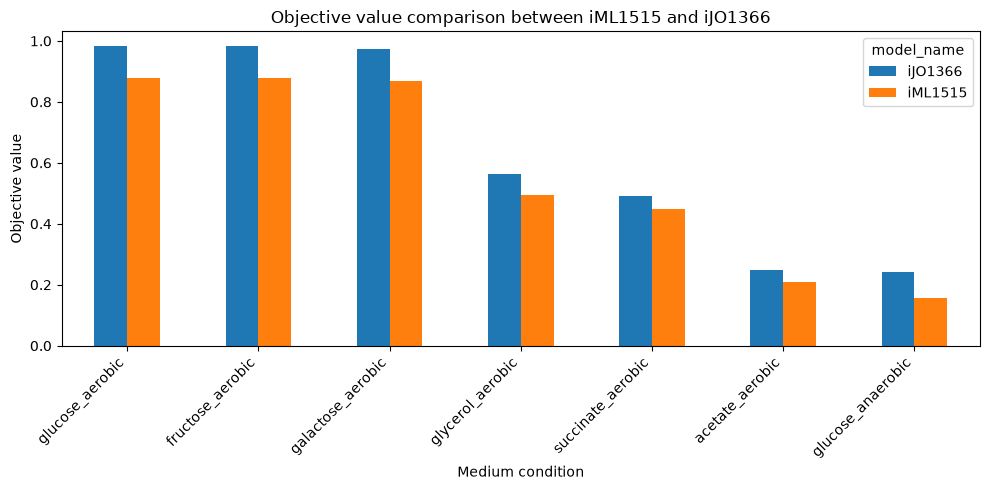

Saved: outputs\figures\ecoli_model_comparison_blocked_reactions.png


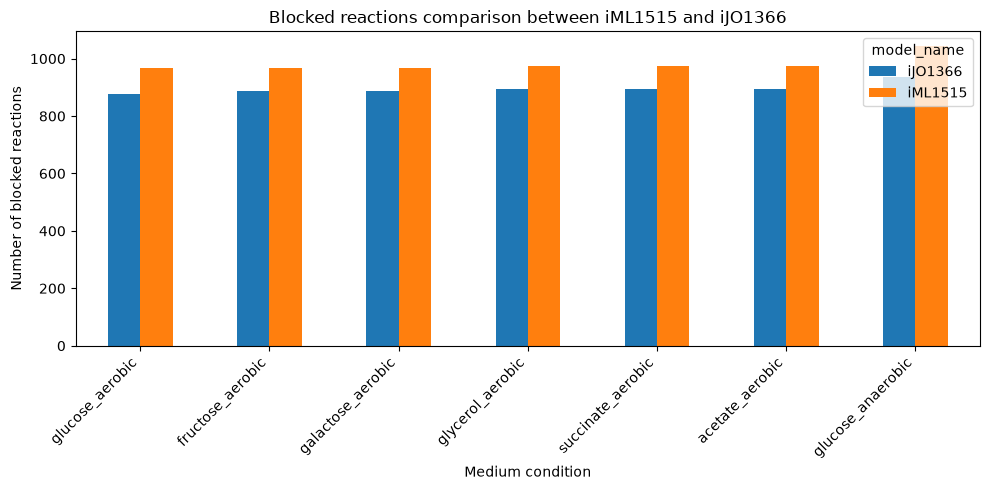

Saved: outputs\figures\ecoli_model_comparison_active_fluxes.png


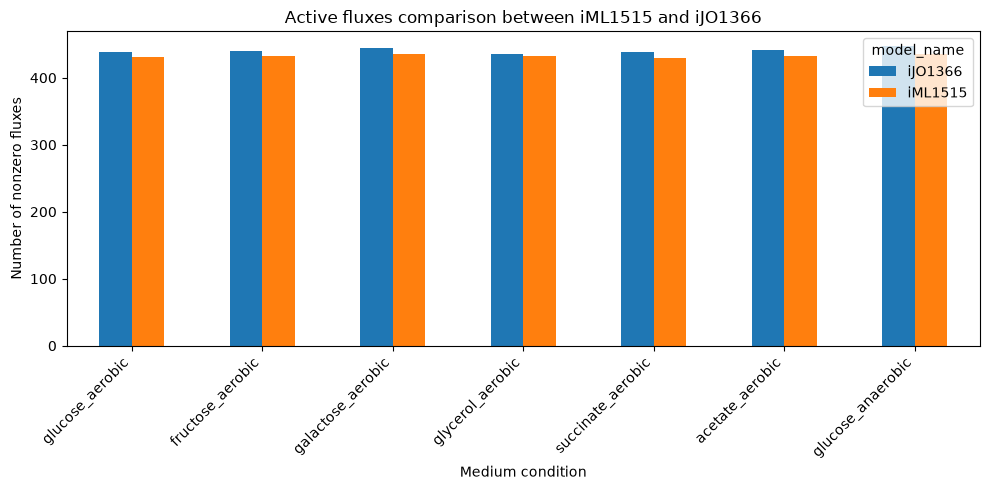

model_name,iJO1366,iML1515,absolute_difference,relative_difference_percent
condition,,,,
glucose_aerobic,0.9824,0.8770,0.1054,12.0154
fructose_aerobic,0.9824,0.8770,0.1054,12.0154
galactose_aerobic,0.9720,0.8676,0.1044,12.0344
glycerol_aerobic,0.5628,0.4947,0.0681,13.7608
succinate_aerobic,0.4925,0.4501,0.0424,9.4200
acetate_aerobic,0.2472,0.2101,0.0371,17.6582
glucose_anaerobic,0.2415,0.1575,0.0840,53.2956


In [15]:
pivot_objective = model_comparison_df.pivot(
    index="condition",
    columns="model_name",
    values="objective_value"
)

pivot_objective = pivot_objective.loc[condition_order]

pivot_objective

ax = pivot_objective.plot(kind="bar", figsize=(10, 5))

plt.title("Objective value comparison between iML1515 and iJO1366")
plt.xlabel("Medium condition")
plt.ylabel("Objective value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

figure_path = figures_dir / "ecoli_model_comparison_objective_value.png"
plt.savefig(figure_path, dpi=300)

print("Saved:", figure_path)
plt.show()

pivot_blocked = model_comparison_df.pivot(
    index="condition",
    columns="model_name",
    values="num_blocked_reactions"
)

pivot_blocked = pivot_blocked.loc[condition_order]

ax = pivot_blocked.plot(kind="bar", figsize=(10, 5))

plt.title("Blocked reactions comparison between iML1515 and iJO1366")
plt.xlabel("Medium condition")
plt.ylabel("Number of blocked reactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

figure_path = figures_dir / "ecoli_model_comparison_blocked_reactions.png"
plt.savefig(figure_path, dpi=300)

print("Saved:", figure_path)
plt.show()

pivot_active = model_comparison_df.pivot(
    index="condition",
    columns="model_name",
    values="num_nonzero_fluxes"
)

pivot_active = pivot_active.loc[condition_order]

ax = pivot_active.plot(kind="bar", figsize=(10, 5))

plt.title("Active fluxes comparison between iML1515 and iJO1366")
plt.xlabel("Medium condition")
plt.ylabel("Number of nonzero fluxes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

figure_path = figures_dir / "ecoli_model_comparison_active_fluxes.png"
plt.savefig(figure_path, dpi=300)

print("Saved:", figure_path)
plt.show()

objective_difference = pivot_objective.copy()

objective_difference["absolute_difference"] = (
    objective_difference["iJO1366"] - objective_difference["iML1515"]
)

objective_difference["relative_difference_percent"] = (
    objective_difference["absolute_difference"] / objective_difference["iML1515"] * 100
)

objective_difference = objective_difference.round(4)

objective_difference



In [16]:
objective_difference_path = tables_dir / "ecoli_model_comparison_objective_differences.csv"

objective_difference.to_csv(objective_difference_path)

print("Saved:", objective_difference_path)

Saved: outputs\tables\ecoli_model_comparison_objective_differences.csv


In [17]:
blocked_difference = pivot_blocked.copy()

blocked_difference["absolute_difference"] = (
    blocked_difference["iML1515"] - blocked_difference["iJO1366"]
)

blocked_difference["relative_difference_percent"] = (
    blocked_difference["absolute_difference"] / blocked_difference["iJO1366"] * 100
)

blocked_difference = blocked_difference.round(4)

blocked_difference

model_name,iJO1366,iML1515,absolute_difference,relative_difference_percent
condition,,,,
glucose_aerobic,878,968,90,10.2506
fructose_aerobic,889,967,78,8.7739
galactose_aerobic,887,966,79,8.9064
glycerol_aerobic,894,973,79,8.8367
succinate_aerobic,894,973,79,8.8367
acetate_aerobic,894,973,79,8.8367
glucose_anaerobic,935,1043,108,11.5508


In [18]:
blocked_difference_path = tables_dir / "ecoli_model_comparison_blocked_reaction_differences.csv"

blocked_difference.to_csv(blocked_difference_path)

print("Saved:", blocked_difference_path)

Saved: outputs\tables\ecoli_model_comparison_blocked_reaction_differences.csv


In [19]:
model_comparison_df.shape

(14, 15)

In [20]:
model_report_table.shape


(14, 8)